**INTODUCTION**
This project performs Exploratory Data Analysis (EDA) on an online retail dataset. The analysis focuses on understanding sales patterns, revenue, products, customers, and trends over time. Data cleaning and statistical analysis are performed using Python and Pandas to identify meaningful business insights.

2.** IMPORT LIBRARIES**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3. **EXTRACT DATASET**

In [6]:
import zipfile

with zipfile.ZipFile("online+retail.zip", "r") as zip_ref:
    zip_ref.extractall("online_retail")

In [7]:
import os

os.listdir("online_retail")

['Online Retail.xlsx']

4. **LOAD DATASET**

In [8]:
df = pd.read_excel("online_retail/Online Retail.xlsx")

**5. DATSET OVERVIEW**

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.shape

(541909, 8)

In [11]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


6**. DATA CLEANING**

In [14]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
df["Quantity"].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [17]:
df["UnitPrice"].describe()

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


In [18]:
df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [19]:
df["Country"].nunique()

38

In [20]:
df_clean = df.copy()

In [21]:
df_clean.shape

(541909, 8)

In [22]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [23]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [24]:
missing_percentage[missing_percentage > 0]

,0
Description,0.268311
CustomerID,24.926694


In [25]:
duplicate_count = df_clean.duplicated().sum()
duplicate_count

np.int64(5268)

In [26]:
duplicate_percentage = (duplicate_count / len(df_clean)) * 100
duplicate_percentage

np.float64(0.9721189350979592)

In [27]:
negative_quantity = (df_clean["Quantity"] < 0).sum()
negative_quantity

np.int64(10624)

In [28]:
zero_price = (df_clean["UnitPrice"] == 0).sum()
zero_price

np.int64(2515)

In [29]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [31]:
df_clean = df_clean.drop_duplicates()

In [30]:
df_clean.shape

(541909, 8)

In [32]:
sales_df = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

In [33]:
sales_df.shape

(524878, 8)

7. ** REVENUE ANALYSIS**

In [34]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [35]:
sales_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [36]:
total_revenue = sales_df["Revenue"].sum()
total_revenue

np.float64(10642110.804)

In [37]:
average_revenue = sales_df["Revenue"].mean()
average_revenue

np.float64(20.27539886221179)

In [38]:
highest_revenue = sales_df["Revenue"].max()
highest_revenue

168469.6

In [39]:
country_revenue = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [40]:
top_country = country_revenue.index[0]
top_country_revenue = country_revenue.iloc[0]

top_country, top_country_revenue

('United Kingdom', np.float64(9001744.094))

8.** PRODUCT REVENUE**

In [41]:
product_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


In [42]:
product_sales = sales_df[
    ~sales_df["Description"].str.contains(
        "POSTAGE|MANUAL|BANK CHARGES|SAMPLES",
        case=False,
        na=False
    )
]

product_revenue_clean = (
    product_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue_clean.head(10)

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


In [43]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [44]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M").astype(str)

9. **. TIME-BASED ANALYSIS**

In [45]:
monthly_revenue = sales_df.groupby("Month")["Revenue"].sum()
monthly_revenue

,Revenue
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [46]:
highest_month = monthly_revenue.idxmax()
highest_month_revenue = monthly_revenue.max()

lowest_month = monthly_revenue.idxmin()
lowest_month_revenue = monthly_revenue.min()

highest_month, highest_month_revenue, lowest_month, lowest_month_revenue

('2011-11', 1503866.78, '2011-02', 522545.56)

**10. CUSTOMER ANALYSIS**

In [47]:
customer_df = sales_df.dropna(subset=["CustomerID"]).copy()

In [48]:
customer_df.shape

(392692, 10)

In [49]:
customer_revenue = (
    customer_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [50]:
product_quantity = (
    product_sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


11.**TRANSACTION ANALYSIS**

In [51]:
unique_orders = sales_df["InvoiceNo"].nunique()
unique_orders

19960

In [52]:
average_items_per_order = sales_df.groupby("InvoiceNo")["Quantity"].sum().mean()
average_items_per_order

np.float64(279.17935871743487)

In [53]:
largest_order = sales_df.groupby("InvoiceNo")["Quantity"].sum().max()
largest_order

80995

**12.KEY FINDINGS**

In [54]:
top_10_countries = country_revenue.head(10)
top_10_countries

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [55]:
country_percentage = (top_10_countries / total_revenue) * 100
country_percentage

,Revenue
Country,
United Kingdom,84.586078
Netherlands,2.682234
EIRE,2.660567
Germany,2.148807
France,1.969772
Australia,1.301000
Spain,0.578443
Switzerland,0.536243
Belgium,0.387107


In [56]:
customer_revenue.describe()

,Revenue
count,4338.000000
mean,2048.688081
std,8985.230220
min,3.750000
25%,306.482500
50%,668.570000
75%,1660.597500
max,280206.020000


In [57]:
customer_revenue.median()

668.57

1. Dataset size

The original dataset contains 541,909 transaction records and 8 columns.

2. Missing data
CustomerID: 24.93% missing
Description: 0.27% missing
Other columns: 0% missing
3. Duplicate data

We found 5,268 duplicate rows, approximately 0.97% of the original dataset, and removed them from our cleaned copy.

4. Valid sales

After excluding negative quantities and zero-price transactions, we created:

524,878 valid sales records.

5. Revenue

We created:

Revenue = Quantity × UnitPrice

This gives us a proper measure for revenue analysis.

6. Top country

🇬🇧 United Kingdom

Revenue:

£9,001,744.094

7. Top actual product by revenue

REGENCY CAKESTAND 3 TIER

Revenue:

£174,156.54

8. Top product by quantity

PAPER CRAFT, LITTLE BIRDIE

Quantity:

80,995 units

9. Highest revenue month

November 2011

Revenue:

£1,503,866.78

10. Lowest revenue month

February 2011

Revenue:

£522,545.56

11. Top customer

Customer ID 14646

Revenue:

£280,206.02

**CONCLUSION**

**CodeAlpha TASK 3 DATA VISUALIZATION**

**1. INTRODUCTION**
This task focuses on presenting the results of the exploratory data analysis through meaningful visualizations. Charts and graphs are used to identify patterns, trends, and important business insights from the Online Retail dataset

**REVENUE BY COUNTRY**

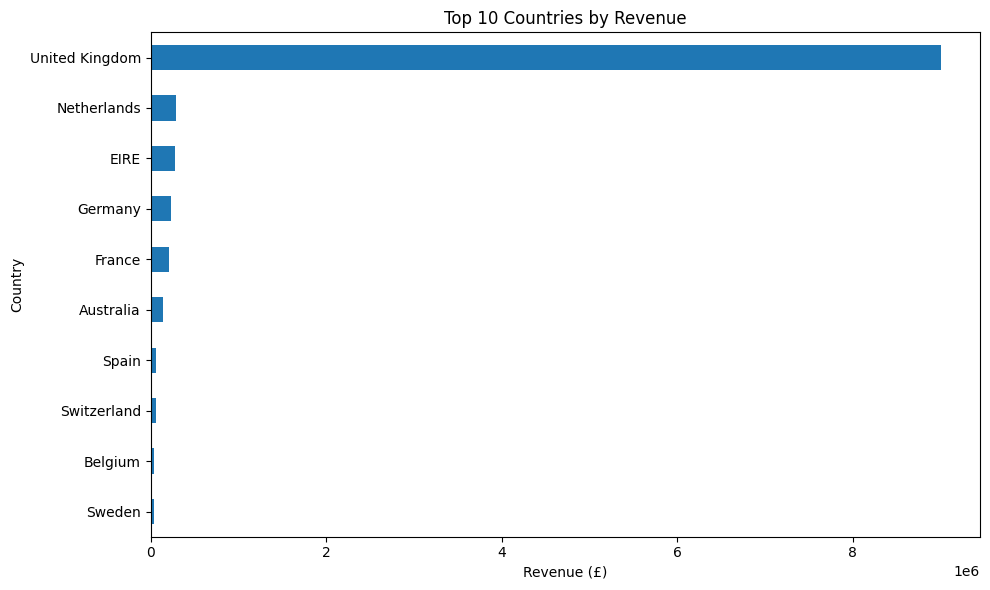

In [58]:
# Top 10 countries by revenue

top_10_countries = country_revenue.head(10)

plt.figure(figsize=(10, 6))
top_10_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

**The United Kingdom generated the highest revenue among all countries, with approximately £9.00 million in valid sales. This indicates that the United Kingdom is the strongest market in the dataset**

**3. TOP 10PRODUCTS BY REVENUE**

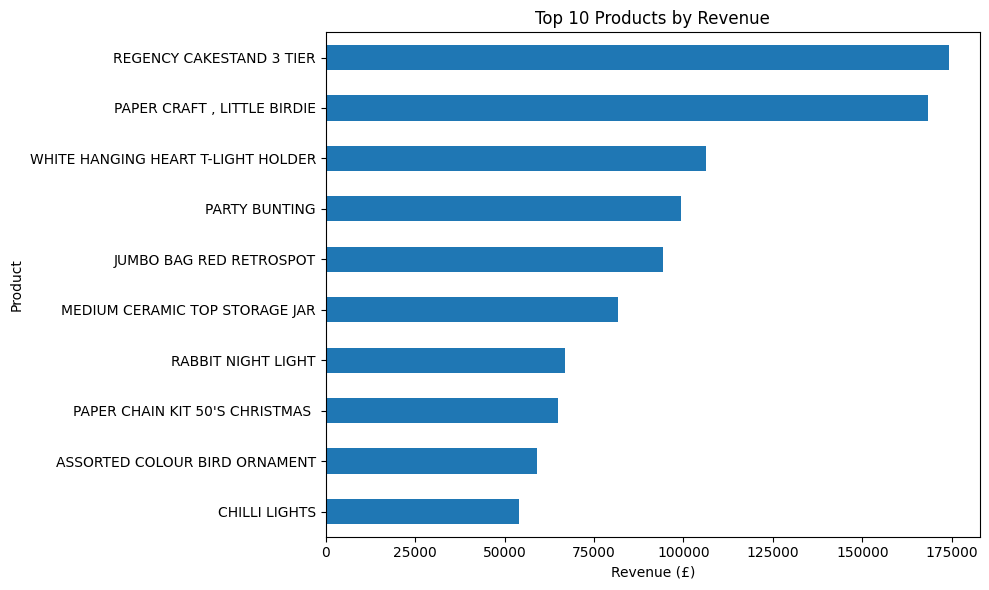

In [59]:
top_10_products = product_revenue_clean.head(10)

plt.figure(figsize=(10, 6))
top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

**REGENCY CAKESTAND 3 TIER generated the highest revenue among the actual products, with approximately £174,157. PAPER CRAFT, LITTLE BIRDIE was the second-highest revenue-generating product, with approximately £168,470.**

**4. MONTHLY REVENUE BY TRENDS**

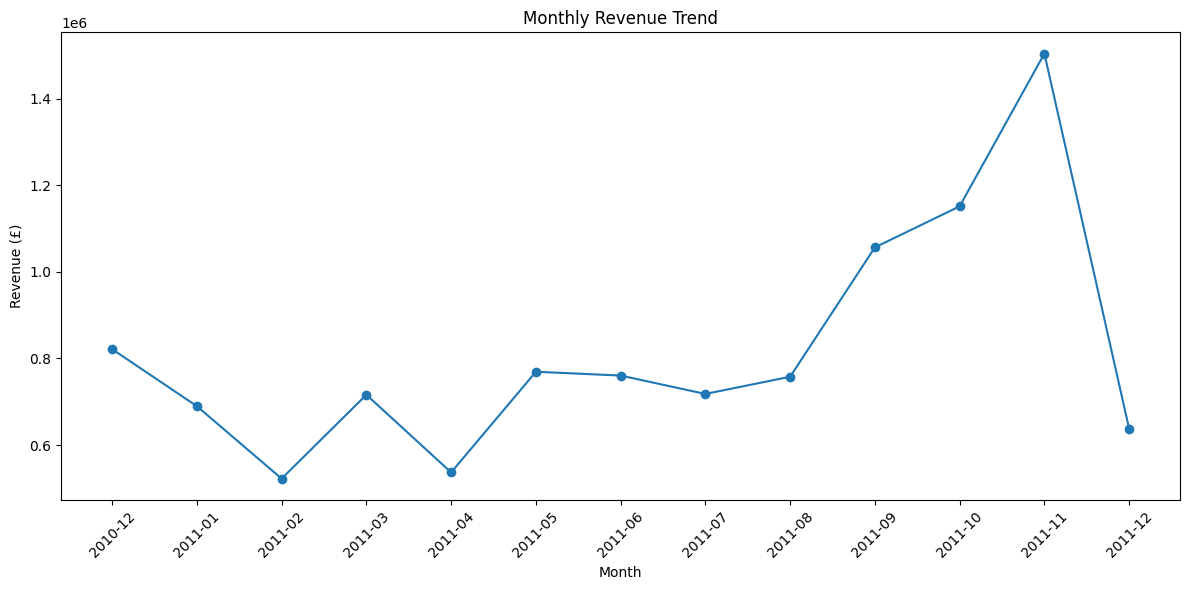

In [60]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Revenue showed fluctuations throughout the period. The highest monthly revenue was recorded in November 2011 at approximately £1.50 million, while February 2011 had the lowest revenue at approximately £522,546. Revenue increased considerably during September, October, and November 2011.**

**5. TOP 10 PRODUCTS BY QUNATITY SOLD**

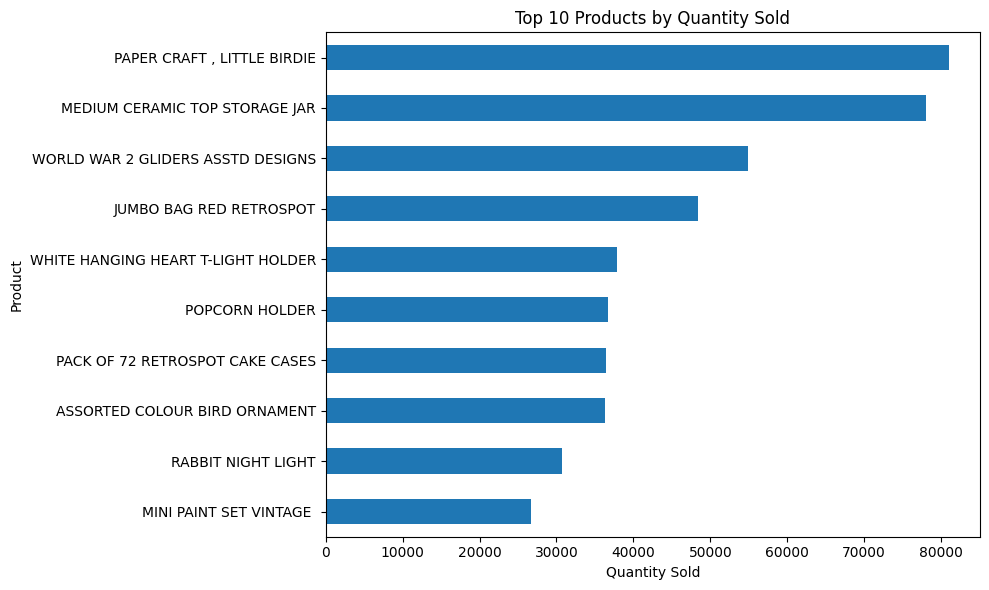

In [61]:
top_10_quantity = product_quantity.head(10)

plt.figure(figsize=(10, 6))
top_10_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

**PAPER CRAFT, LITTLE BIRDIE was the most frequently purchased product, with 80,995 units sold. MEDIUM CERAMIC TOP STORAGE JAR was the second-highest, with 78,033 units sold.**

**6. TOP 10 CUSTOMERS BY REVENUE**

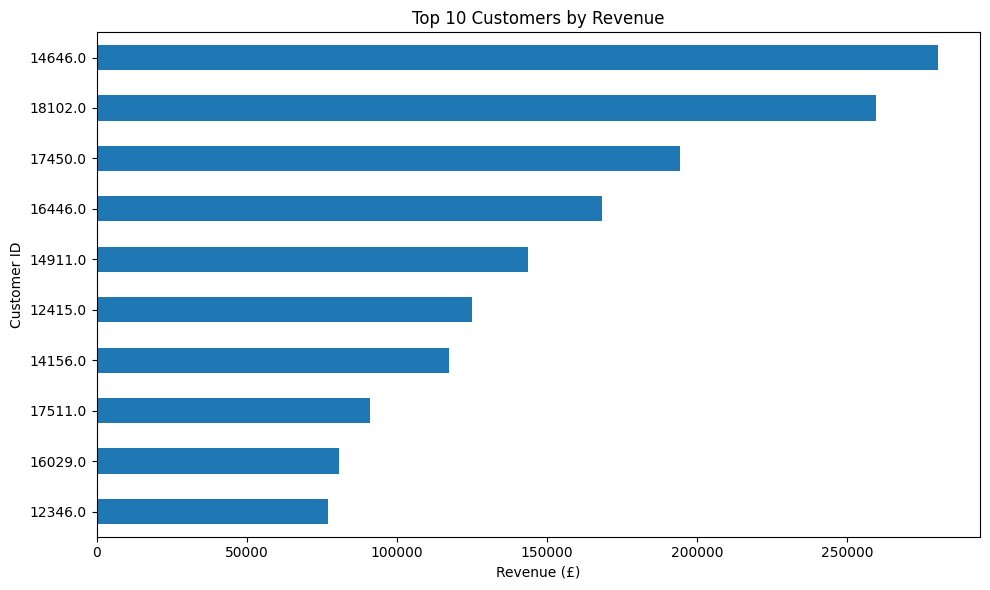

In [62]:
top_10_customers = customer_revenue.head(10)

plt.figure(figsize=(10, 6))
top_10_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

**Customer 14646 generated the highest revenue, contributing approximately £280,206. Customer 18102 was the second-highest revenue-generating customer, contributing approximately £259,657. These high-value customers may be important for customer retention and loyalty strategies.**

**7. KEY FINDINGS**

The visualizations provide several important insights from the Online Retail dataset:

1. The United Kingdom was the strongest market, generating approximately £9.00 million in revenue.

2. REGENCY CAKESTAND 3 TIER generated the highest revenue among the actual products, with approximately £174,157.

3. PAPER CRAFT, LITTLE BIRDIE had the highest quantity sold, with 80,995 units.

4. November 2011 recorded the highest monthly revenue at approximately £1.50 million, while February 2011 recorded the lowest at approximately £522,546.

5. Customer 14646 was the highest revenue-generating customer, contributing approximately £280,206.

6. The product with the highest quantity sold was not the same as the product with the highest revenue, showing that sales volume and revenue provide different business insights.

**8. CONCLUSION**

This data visualization task transformed the results of the exploratory data analysis into clear and meaningful charts. The visualizations made it easier to identify the strongest markets, top-performing products, customer contributions, and monthly revenue trends. These insights can help businesses understand sales performance and support better decisions related to products, customers, and market strategies.